# Simple Linear Regression
Regression analysis is used to predict the value of one variable on the basis of other variables. This technique may be the most commonly used statistical procedure.
<center><img src="Images/Linear Regression/1.png" width=750></center>

The model (15.2.1) is called the simple linear regression model because it is linear in regard to the parameters β0 and β1. Furthermore, since the model is also linear in the predictor variable X, this regression model is called a first-order linear model.

It should be noted that in dealing with the mathematical models (15.2.1) the variable X is assumed controlled, or measured, without error, and all the random variability is attributed to the observation Y at each fixed value of X. In practice,
controlling or measuring X exactly is often impossible. However, it is assumed that the values of X are known much more precisely than those of the response, Y, and indeed the analysis proceeds by assuming the independent variable, X, can be fixed without error.

b1 (point estimate of β1) is a random variable having a normal distribution.
<center><img src="Images/Linear Regression/2.png" width=750></center>

In [9]:
from math import sqrt

import pandas as pd
from pandas import DataFrame
import numpy as np

from sklearn.linear_model import LinearRegression
from scipy.stats import t, chi2, norm, f, binom
import statsmodels.api as sm

# For data visualization
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## Problem Statement - Fuel Cumsuption vs. Engine Size
Throughout this notebook, I use the Fuel Consumption data. The problem statement is to find if there is any linear relationships between the size of engine in a car and it's fuel consumption.<br>
**(a)** Construct a scatter plot for this data and draw a straight-line to examine if the simple linear regression model seems to be an adequate model for these data.<br>
**(b)** Find the fitted regression line for these data.<br>
**(c)** Find a 95% confidence interval for E(Y |X = 0.25).<br>
**(D)** Find a 95% prediction interval for Y at X = 0.25.

In [8]:
data = pd.read_csv('Data/FuelConsumptionCo2.csv')
data.head(3)

,Engine Size,CO2 Emissions
0,2.0,196
1,2.4,221
2,1.5,136


In [106]:
# Remove Duplicates
df = data.drop_duplicates().sort_values(by='Engine Size')
df.shape

(531, 2)

In [146]:
X = df[['Engine Size']]
Y = df['CO2 Emissions']

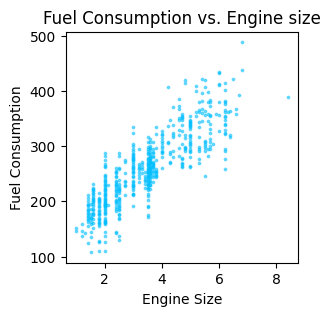

In [147]:
fig = plt.figure(figsize=(3, 3))
ax = plt.axes()
ax.scatter(X, Y, c='#00BFFF', s=3, alpha=0.5)
ax.set(xlabel='Engine Size', ylabel='Fuel Consumption', title='Fuel Consumption vs. Engine size')

plt.draw()

### Linear Regression Using statsmodel

In [148]:
# X = sm.add_constant(X)

model = sm.OLS(Y, X)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:          CO2 Emissions   R-squared (uncentered):                   0.952
Model:                            OLS   Adj. R-squared (uncentered):              0.952
Method:                 Least Squares   F-statistic:                          1.062e+04
Date:                Sun, 13 Apr 2025   Prob (F-statistic):                        0.00
Time:                        16:13:14   Log-Likelihood:                         -2915.7
No. Observations:                 531   AIC:                                      5833.
Df Residuals:                     530   BIC:                                      5838.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [149]:
print(f"coefficient of determination: {results.rsquared}")
print(f"adjusted coefficient of determination: {results.rsquared_adj}")
print(f"regression coefficients: {results.params}")


coefficient of determination: 0.952462648597284
adjusted coefficient of determination: 0.9523729554814299
regression coefficients: Engine Size    69.764598
dtype: float64


In [150]:
fitted_values = results.fittedvalues
predicted_response = results.predict(X)

### Linear Regression Using sklearn

In [151]:
model = LinearRegression(fit_intercept=True)
model.fit(X, Y)
y_hat = model.predict(X)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [40.02246849]
Intercept: 121.39844605066673


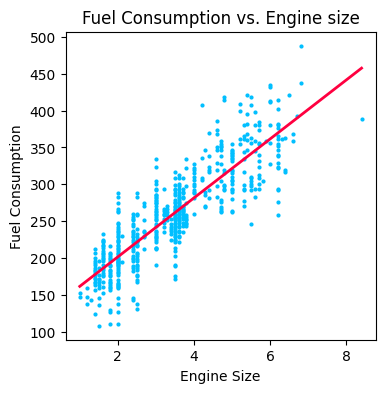

In [152]:
fig = plt.figure(figsize=(4, 4))
ax = plt.axes()
ax.scatter(X, Y, c='#00BFFF', s=4)
ax.plot(X, y_hat, color="#FF0040", linewidth=2, label='Fitted Line')
ax.set(xlabel='Engine Size', ylabel='Fuel Consumption', title='Fuel Consumption vs. Engine size')

plt.draw()

In [114]:
# C
b0 = model.intercept_
b1 = model.coef_
SXX = 0.01425
x_bar = np.mean(X)
S = 1.36

We note that this regression line is valid for values of X that lie in the experimental region,
i.e., 0.21 ≤ X ≤ 0.33. Indeed, outside this interval, E(Y |X) could be quadratic in X, or
exponential, etc. We further note that X = 0.25 lies in [0.21, 0.33]. Hence, Y_hat at X = 0.25
is equal to:
$$\hat{Y} = 56.716 + 90.526(0.25) = 79.3475$$
that is, the point estimate of E(Y |X = 0.25) is 79.3475.


In [115]:
x = 0.25
y_hat = b0 + b1 * x
n = 10
alpha = 0.05
t_stat = t.ppf(1-alpha/2, n-2)
le = y_hat  - t_stat * S * sqrt(1/n + (x - x_bar)**2/SXX)
re = y_hat  + t_stat * S * sqrt(1/n + (x - x_bar)**2/SXX)

print(f"The 95% confidence interval for E(Y |X = 0.25), is ({le}, {re})")

# D
le = y_hat  - t_stat * S * sqrt(1 + 1/n + (x - x_bar)**2/SXX)
re = y_hat  + t_stat * S * sqrt(1 + 1/n + (x - x_bar)**2/SXX)

print(f"The 95% confidence interval for Y at X = 0.25, is ({le}, {re})")

The 95% confidence interval for E(Y |X = 0.25), is ([46.74681302], [216.06131332])
The 95% confidence interval for Y at X = 0.25, is ([46.68874261], [216.11938373])


## Confidence Interval for β1 with Confidence Coefficient (1 − α)
<center><img src="Images/Linear Regression/4.png" width=750></center>

The slope coefficient b1 means that for each additional unit of x, the dependent variable y changes by an average of b1.

## Confidence Interval for β0 with Confidence Coefficient (1 − α)
<center><img src="Images/Linear Regression/5.png" width=750></center>

## Analysis of Variance Approach to Simple Linear Regression


## Assessing the Model
- Sum of Squares for Error
- Standard error of estimate
- t-test of the slope
- Coefficient of determination


### Sum of Squares for Error
<center><img src="Images/Linear Regression/12.png" width=750></center>

### Standard Error of Estimate
The error variable ε is normally distributed with mean 0 and standard deviation $σ_ε$. If $σ_ε$ is large, some of the errors will be large, which implies that the model’s fit is poor. If $σ_ε$ is small, the errors tend to be close to the mean
(which is 0); as a result, the model fits well. Hence, we could use $σ_ε$ to measure the suitability of using a linear model. Unfortunately, $σ_ε$ is a population parameter and, like most other parameters, is unknown. We can, however, estimate $σ_ε$ from the data. The estimate is based on SSE. The unbiased estimator of the variance of the error variable $σ_ε^2$ is:
<center><img src="Images/Linear Regression/7.png" width=750></center>

The smallest value that $s_ε$ can assume is 0, which occurs when SSE = 0, that is, when all the points fall on the regression line. Thus, when $σ_ε$ is small, the fit is excellent, and the linear model is likely to be an effective analytical and forecasting tool. If $σ_ε$ is large, the model is a poor one, and the statistics practitioner should improve it or discard it.
We judge the value of $σ_ε$ by comparing it to the values of the dependent variable y or more specifically to the sample mean y.

### T-test of the Slope (β1)
H0: β1 = 0<br>
H1: β1 ≠ 0<br>
<center><img src="Images/Linear Regression/8.png" width=750></center>

### Coefficient of Determination
The test of β1 addresses only the question of whether there is enough evidence to infer
that a linear relationship exists. In many cases, however, it is also useful to measure the
strength of that linear relationship, particularly when we want to compare several different models. The statistic that performs this function is the coefficient of determination, which is denoted $R^2$. Statistics practitioners often refer to this statistic as the **R-square.**

<center><img src="Images/Linear Regression/9.png" width=750></center>

### Testing the Coefficient of Correlation
In many circumstances, we’re interested in determining only whether a linear relationship exists and not the form of the relationship. **When the data are observational and the two variables are bivariate normally distributed we can calculate the coefficient of correlation and use it to test for linear association**.<br>
The population coefficient of correlation is denoted ρ (the Greek letter rho). Because ρ is a population parameter (which is almost always unknown), we must estimate its value from the sample data. Recall that the sample coefficient of correlation is defined as follows.
<center><img src="Images/Linear Regression/13.png" width=750></center>

H0: ρ = 0<br>
H1: ρ ≠ 0

The test statistic is defined in the following way.
<center><img src="Images/Linear Regression/14.png" width=750></center>

Notice that the t-test of ρ and the t-test of β1 produce identical
results. This should not be surprising because both tests are conducted to determine
whether there is evidence of a linear relationship.<br>

The decision about which test to use is based on the type of experiment and the information we seek from the statistical
analysis. 
- If we’re interested in discovering the relationship between two variables, or
if we’ve conducted an experiment where we controlled the values of the independent
variable, the t-test of β1 should be applied.
- If we’re interested only in determining whether two random variables that are bivariate normally distributed are
linearly related, the t-test of ρ should be applied.<br>
As is the case with the t-test of the slope, we can also conduct one-tail tests. We can
test for a positive or a negative linear relationship.

## Prediction Using the Regression Equation
### Point Prediction
Using the techniques in the previous section, we can assess how well the linear model fits the data. If the model fits satisfactorily, we can use it to forecast and estimate values of the dependent variable.<br>
Using the regression equation, with x = 40, we get<br>
y_hat = 17.250 − .0669x = 17.250 − 0.0669(40) = 14.574<br>
y_hat is the point estimate or predicted value for y when x = 40. By itself, however, the point prediction does not provide any information about how closely the value will match the true selling price. To discover that information, we
must use an interval. In fact, we can use one of two intervals:
- The prediction interval of a particular value of y
- The confidence interval estimator of the expected value of y

### Confidence Interval for E(Y |X) with Confidence Coefficient (1 − α)
<center><img src="Images/Linear Regression/3.png" width=750></center>

### Prediction Interval for a Future Observation Y with Confidence Coefficient (1 − α)
<center><img src="Images/Linear Regression/6.png" width=750></center>


Unlike the formula for the prediction interval, this formula does not include the
1 under the square-root sign. As a result, the confidence interval estimate of the
expected value of y will be narrower than the prediction interval for the same given
value of x and confidence level. This is because there is less error in estimating a mean
value as opposed to predicting an individual value.

### Effect of the Given Value of x on the Intervals
<center><img src="Images/Linear Regression/15.png" width=750></center>

## R-Squared and p-value for Hypothesis Test of β1
The estimate of the coefficient of determination is given by R2 = 1 − SSE/SST, where
SST = sigma(Yi − Y_bar )**2. The value of R2 should be used cautiously and in conjunction with
the p-value for the test H0 : β1 != 0 versus H0 : β1 = 0. Some general rules for using R2
along with the p-value are:<br>
1. A high value of R2, coupled with a very small p-value for Ho : β1 = 0, (say) less than
5%, may indicate a strong linear relationship between the response variable and the
predictor variable, provided that the residual plots indicate no abnormality.
2. A high value of R2 and a large p-value for the test H0 : β1 = 0 versus H0 : β1 != 0
may indicate a strong curvilinear relationship between the response variable and the
predictor variable (see Example 15.7.1).
3. A low value of R2 and a large p-value do not necessarily preclude the existence
of a relationship between the response variable and the predictor variable. Rather,
this may simply mean there is a strong curvilinear relationship between them.

## Summary of Linear Regression Calculations
<center><img src="Images/Linear Regression/10.png" width=750></center>

## Regression Diagnostics (Residual Analysis)
Required Conditions for the Error Variable
1. The probability distribution of ε is normal.
2. The mean of the distribution is 0; that is, E(ε) = 0.
3. The standard deviation of ε is $σ_ε$, which is a constant regardless of the value of x (homoscedasticity).
4. The value of ε associated with any particular value of y is independent of ε associated with any other value of y.
Simply put, the error variable must be normally distributed with a constant variance, and the errors must be independent of each other.

Requirements 1, 2, and 3 can be interpreted in another way: For each value of x, y is a normally distributed random variable whose mean is<br>
E( y) = β0 + β1x<br>
and whose standard deviation is $σ_ε$. Notice that the mean depends on x. The standard deviation, however, is not influenced by x because it is a constant over all values of x.<br>
Figure 16.3 depicts this interpretation. Notice that for each value of x, E(y) changes, but the shape of the distribution of y remains the same. In other words, for each x, y is normally distributed with the same standard deviation.
<center><img src="Images/Linear Regression/11.png" width=350></center>

### The probability distribution of ε is normal?

In [116]:
fitted_values = results.fittedvalues
predicted_response = results.predict(X)
sum(fitted_values == predicted_response)
len(fitted_values)

531

In [153]:
residuals = predicted_response - Y
residuals.skew()


0.5887426789557266

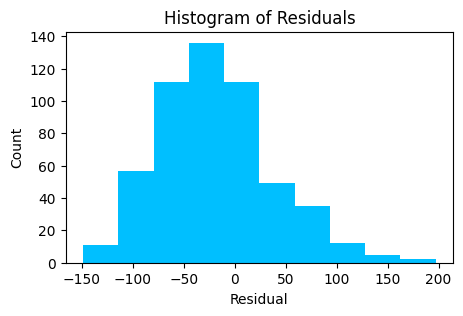

In [154]:
fig = plt.figure(figsize=(5, 3))
ax = plt.axes()
ax.hist(residuals, color='#00BFFF')
ax.set(xlabel='Residual', ylabel='Count', title='Histogram of Residuals')
plt.draw()

### The mean of the distribution is 0; that is, E(ε) = 0?

In [155]:
np.mean(residuals)

-18.129963004810705

### The standard deviation of ε is $σ_ε$, which is a constant regardless of the value of x? (Homoscedasticity)

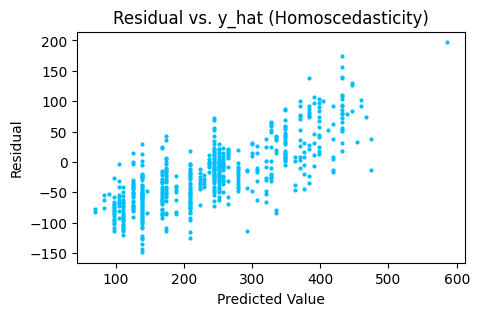

In [172]:
fig = plt.figure(figsize=(5, 3))
ax = plt.axes()
ax.scatter(predicted_response, residuals, c='#00BFFF', s=4)

ax.set(xlabel='Predicted Value', ylabel='Residual', title='Residual vs. y_hat (Homoscedasticity)')

plt.draw()

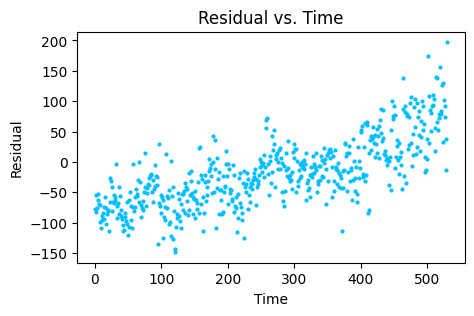

In [173]:
# Residual vs. Observation Order
xs = range(X.shape[0])

fig = plt.figure(figsize=(5, 3))
ax = plt.axes()
ax.scatter(xs, residuals, c='#00BFFF', s=4)
ax.set(xlabel='Time', ylabel='Residual', title='Residual vs. Time')

plt.draw()

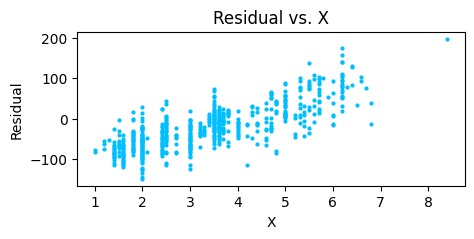

In [170]:
# Residuals vs. X
fig = plt.figure(figsize=(5, 2))
ax = plt.axes()
ax.scatter(X, residuals, c='#00BFFF', s=4)
ax.set(xlabel='X', ylabel='Residual', title='Residual vs. X')

plt.draw()

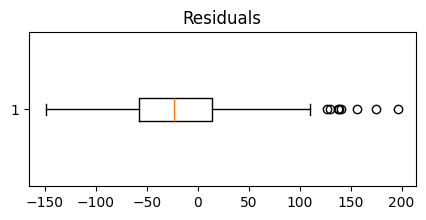

In [169]:
# Residuals Outliers
fig = plt.figure(figsize=(5, 2))
ax = plt.axes()
ax.boxplot(residuals, vert=False)

ax.set(title='Residuals')

plt.draw()


## Transformation

Normality and stabilization of variance often go hand in hand. To stabilize the variance, transformations, such as the log, square root, or reciprocal of the response variables,
are usually used. If the normality, common variance, and independence assumptions are
fairly satisfactory, then, for linearization, transformations of the predictor variable such as
$X^2$, $\log{X}$, $\sqrt{X}$ or $\frac{1}{X}$ may work quite well. However, several transformations should be
tried on the response variable, predictor variable, or both, and the residual analysis done to
find which transformation works best. Sometimes one transformation may need to be used
on the response variable and another on the predictor variable. Other transformations, for
example, to linearize the nonlinear models mentioned above that may work well, are
<center><img src="Images/Linear Regression/16.png" width=750></center>